# Collector Missing Data Spots

Lists collector polling gaps and estimates missed polls and rows.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "collector_missing_data_spots",
    PROJECT_ROOT / "analysis" / "collector-missing-data-spots.py",
)
missing_data = importlib.util.module_from_spec(spec)
spec.loader.exec_module(missing_data)

DB = PROJECT_ROOT / "data" / "foli.db"
SOURCE = None
LIMIT = 20
MIN_OBSERVATIONS = 1
GAP_MULTIPLIER = 2.0
MIN_MISSING_MINUTES = 0.0

In [2]:
class Args:
    db = DB
    source = SOURCE
    limit = LIMIT
    min_observations = MIN_OBSERVATIONS
    gap_multiplier = GAP_MULTIPLIER
    min_missing_minutes = MIN_MISSING_MINUTES

polls = missing_data.load_polls(Args)
spots = missing_data.build_missing_spots(polls, GAP_MULTIPLIER, MIN_MISSING_MINUTES)
summary = missing_data.summarize_missing_spots(spots, polls)
summary

,source,poll_count,success_count,failed_count,missing_spot_count,total_missing_min,largest_missing_min,estimated_missed_polls,estimated_missed_rows
2,siri_vm,10756,10726,30,7,49.95,18.43,99.90,12084.80
1,siri_alerts,1091,1084,7,1,13.17,13.17,2.63,39.66
0,gtfs,1,1,0,0,0.00,0.00,0.00,0.00


In [3]:
spots.head(LIMIT)

,source,gap_start_utc,gap_end_utc,gap_min,expected_cadence_seconds,missing_min,estimated_missed_polls,estimated_missed_rows,failed_attempt_count,next_success_status
3,siri_vm,2026-04-24T10:36:16+00:00,2026-04-24T10:55:12+00:00,18.93,30.0,18.43,36.87,4459.72,7,OK
0,siri_alerts,2026-04-24T10:35:49+00:00,2026-04-24T10:53:59+00:00,18.17,300.0,13.17,2.63,39.66,6,OK
2,siri_vm,2026-04-23T23:59:42+00:00,2026-04-24T00:08:25+00:00,8.72,30.0,8.22,16.43,1987.92,5,OK
6,siri_vm,2026-04-26T00:00:03+00:00,2026-04-26T00:08:20+00:00,8.28,30.0,7.78,15.57,1883.08,5,OK
5,siri_vm,2026-04-25T00:00:19+00:00,2026-04-25T00:08:35+00:00,8.27,30.0,7.77,15.53,1879.05,5,OK
7,siri_vm,2026-04-27T00:00:32+00:00,2026-04-27T00:04:47+00:00,4.25,30.0,3.75,7.50,907.27,4,OK
4,siri_vm,2026-04-24T10:55:12+00:00,2026-04-24T10:57:55+00:00,2.72,30.0,2.22,4.43,536.30,3,OK
1,siri_vm,2026-04-23T10:22:02+00:00,2026-04-23T10:24:19+00:00,2.28,30.0,1.78,3.57,431.46,1,OK


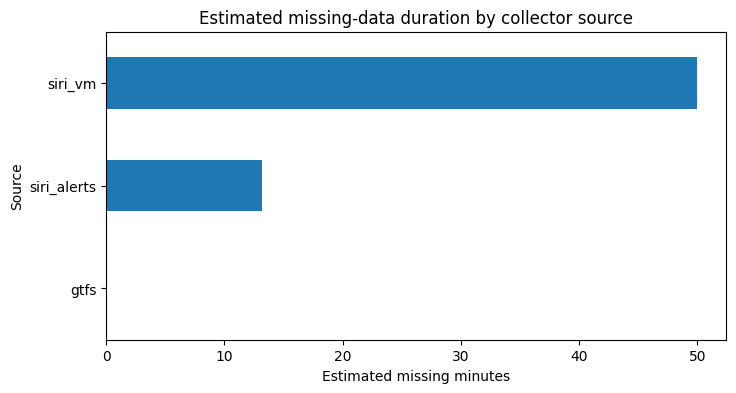

In [4]:
if not summary.empty:
    ax = summary.sort_values("total_missing_min").plot.barh(
        x="source",
        y="total_missing_min",
        legend=False,
        figsize=(8, 4),
        title="Estimated missing-data duration by collector source",
    )
    ax.set_xlabel("Estimated missing minutes")
    ax.set_ylabel("Source")